# Реализация и анализ алгоритма Q-learning, Q-learning + Dyna на детерминированной среде

In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import imageio
from PIL import Image
from collections import defaultdict
from tqdm import tqdm
import os
os.environ["XDG_RUNTIME_DIR"] = "/tmp"

from IPython.display import display, Image as IPyImage
from PIL import Image

## Гиперпараметры

In [2]:
seeds = [42, 69]
alpha = 0.1
gamma = 0.99
epsilon = 0.1
episodes = 2000 
planning_steps = 20
env_name = "Taxi-v3"

## Функции

In [3]:
# Функция скользящего среднего для сглаживания кривых
def moving_avg(x, window=100):
    return np.convolve(x, np.ones(window)/window, mode='valid')

# Q-learning без модели мира
def q_learning(seed):
    env = gym.make(env_name)
    random.seed(seed)
    np.random.seed(seed)
    env.reset(seed=seed)
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    
    Q = np.zeros((n_states, n_actions))
    rewards = []
    
    for ep in tqdm(range(episodes)):
        state, _ = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            # ε-greedy
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Обновление Q
            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )
            state = next_state
            total_reward += reward
        
        rewards.append(total_reward)
    
    env.close()
    return Q, rewards

# Dyna-Q: Q-learning + модель переходов
def dyna_q(seed):
    env = gym.make(env_name)
    random.seed(seed)
    np.random.seed(seed)
    env.reset(seed=seed)
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    
    Q = np.zeros((n_states, n_actions))
    model = dict()  # хранит (state, action) -> (next_state, reward)
    rewards = []
    
    for ep in tqdm(range(episodes)):
        state, _ = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Обновление Q
            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )
            # Сохраняем в модель
            model[(state, action)] = (next_state, reward)
            
            # Планирование
            for _ in range(planning_steps):
                s, a = random.choice(list(model.keys()))
                s_next, r = model[(s, a)]
                Q[s, a] += alpha * (
                    r + gamma * np.max(Q[s_next]) - Q[s, a]
                )
            
            state = next_state
            total_reward += reward
        
        rewards.append(total_reward)
    
    env.close()
    return Q, rewards

## Запуск экспериментов

In [4]:
Qs_q, Qs_dyna = [], []
rewards_q, rewards_dyna = [], []

for seed in seeds:
    Q_q, r_q = q_learning(seed)
    Q_d, r_d = dyna_q(seed)
    Qs_q.append(Q_q); rewards_q.append(r_q)
    Qs_dyna.append(Q_d); rewards_dyna.append(r_d)


100%|███████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:32<00:00, 62.34it/s]


## Визуализация

Генерация графиков...


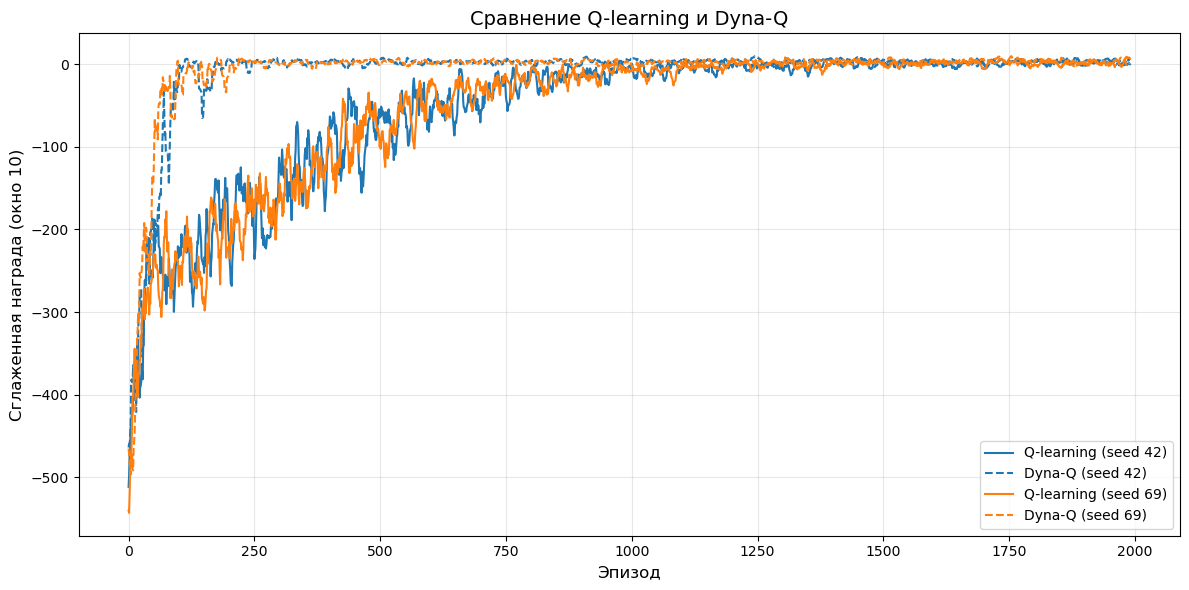

In [9]:
def plot_results(rewards_q, rewards_dyna, seeds):
    plt.figure(figsize=(12, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    smooth_window = 10  # Размер окна для сглаживания
    smooth = lambda x: np.convolve(np.nan_to_num(x), 
                                 np.ones(smooth_window)/smooth_window, 
                                 mode='valid')
    
    for i, (r_q, r_dyna) in enumerate(zip(rewards_q, rewards_dyna)):
        plt.plot(smooth(r_q), color=colors[i], linestyle='-', label=f'Q-learning (seed {seeds[i]})')
        plt.plot(smooth(r_dyna), color=colors[i], linestyle='--', label=f'Dyna-Q (seed {seeds[i]})')
    
    plt.title("Сравнение Q-learning и Dyna-Q", fontsize=14)
    plt.xlabel("Эпизод", fontsize=12)
    plt.ylabel(f"Сглаженная награда (окно {smooth_window})", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print('Генерация графиков...')
plot_results(rewards_q, rewards_dyna, seeds)

## Генератор GIF для всех политик

taxi_q_learning.gif


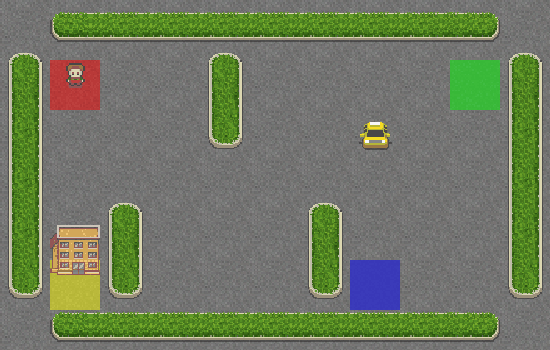

taxi_dyna_q.gif


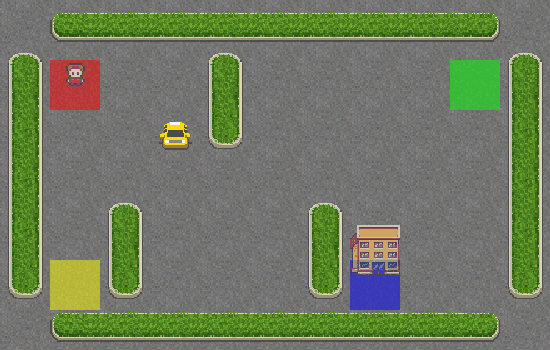

In [8]:
def generate_gif(Q, filename="agent.gif", max_steps=200):
    env = gym.make(env_name, render_mode="rgb_array")
    state, _ = env.reset()
    frames = []
    
    for _ in range(max_steps):
        frame = env.render()
        frames.append(Image.fromarray(frame))  # Используем PIL.Image
        action = np.argmax(Q[state])
        state, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break
    
    env.close()
    frames[0].save(
        filename, save_all=True, append_images=frames[1:], duration=200, loop=0
    )
    print(filename)
    display(IPyImage(filename=filename))  # Используем IPython.display.Image

# Генерация гифок по первой модели каждого алгоритма
generate_gif(Qs_q[0], filename="taxi_q_learning.gif")
generate_gif(Qs_dyna[0], filename="taxi_dyna_q.gif")

## Выводы

### 1. Сравнение алгоритмов

Dyna-Q показал значительно более быструю сходимость, чем Q-learning:

- Среднее вознаграждение достигает нуля уже к 100 эпизодам (против 1000 у Q-learning).

- Стабилизация к 250 эпизодам (против 1250 у Q-learning).

Это подтверждает, что планирование на модели (planning_steps) ускоряет обучение, так как агент использует искусственный опыт для обновления Q-таблицы.

### 2. Анализ гиперпараметров

alpha = 0.1:

- Оптимален для данной среды – обеспечивает быстрое обучение без перешумления.

- Уменьшение (например, до 0.01) замедляет сходимость, увеличение (например, до 0.5) делает обучение нестабильным.

epsilon = 0.1:

- Хороший баланс между исследованием и эксплуатацией.

- При epsilon=0.01 агент быстро становится жадным, при epsilon=0.5 – совершает много случайных действий, что снижает эффективность.

planning_steps = 20:

- Лучший компромисс между скоростью и стабильностью.

- Увеличение до 50+ не даёт значимого улучшения, а уменьшение до 5 замедляет Dyna-Q.